# Lab 5 - Visualization and Mini-EDA

This lab focuses on exploring and visualizing data using different visualization techniques and performing a mini exploratory data analysis.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("../week2-eda/data/train.csv")

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Dataset Overview

First, we inspect the dataset to understand its structure, number of rows and columns, and data types.

In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 2. Missing Values

We check the dataset for missing values to understand which columns require data cleaning.

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing

,Missing Count,Missing Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


## 3. Age Distribution

A histogram is used to understand the distribution of passenger ages. The KDE curve helps visualize the overall shape of the distribution.

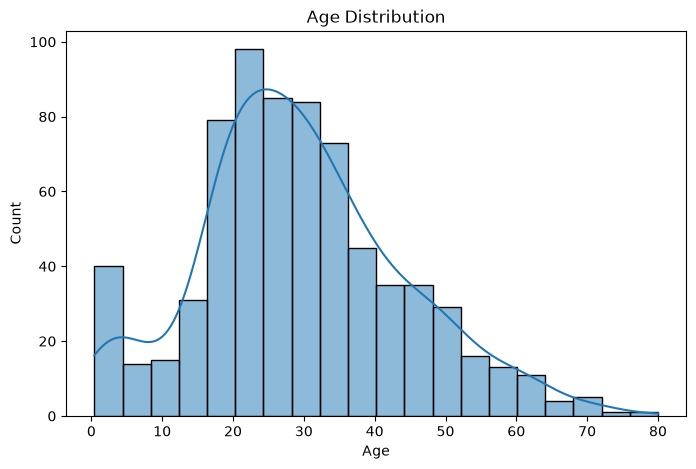

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"].dropna(), bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

## 4. Age Boxplot

A boxplot is used to understand the median, quartiles, spread, and potential outliers in passenger ages.

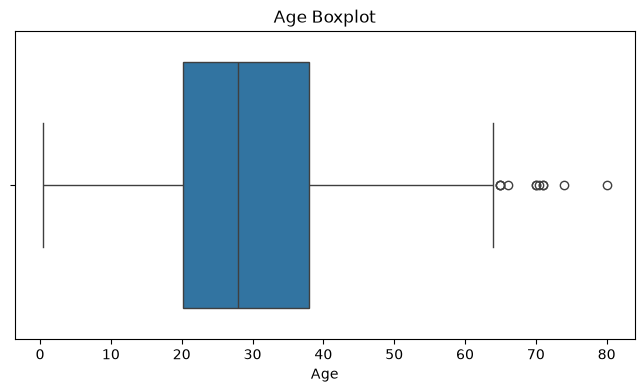

In [16]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Age"])

plt.title("Age Boxplot")
plt.xlabel("Age")

plt.show()

## 5. Survival Analysis

We analyze the survival rate of passengers using different categories to understand which groups had higher survival rates.

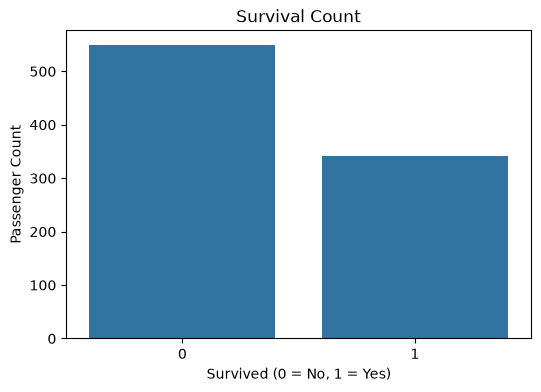

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Survived", data=df)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passenger Count")

plt.show()

## 6. Survival by Gender

We compare survival outcomes between male and female passengers.

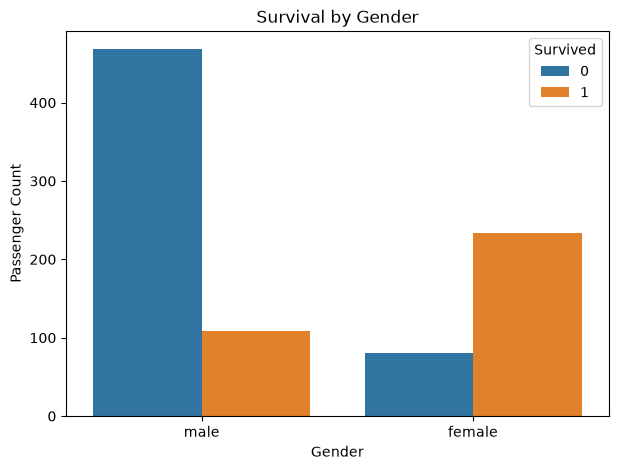

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Count")

plt.show()

## 7. Survival by Passenger Class

Passenger class is analyzed to determine whether survival outcomes differed between first, second, and third class passengers.

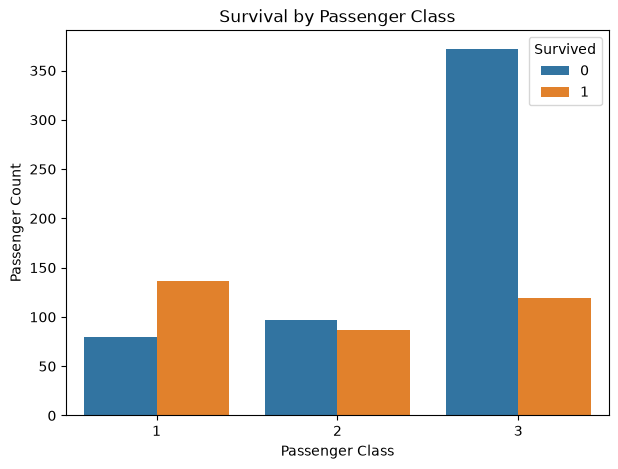

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")

plt.show()

## 8. Fare Distribution

A histogram is used to understand how ticket fares are distributed among passengers.

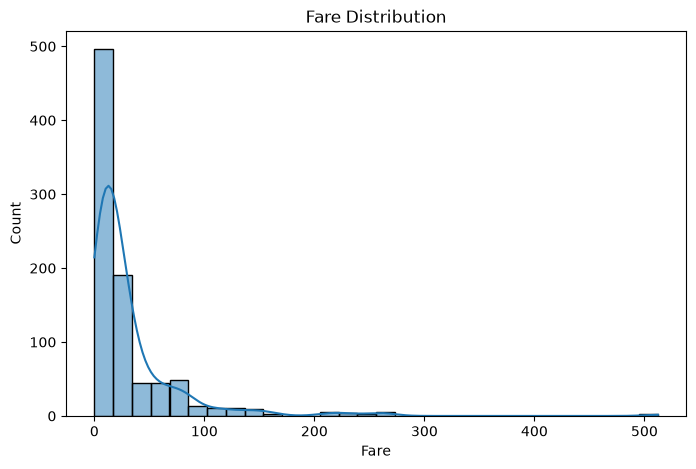

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.show()

## 9. Correlation Analysis

A correlation heatmap is used to identify relationships between numerical variables in the dataset.

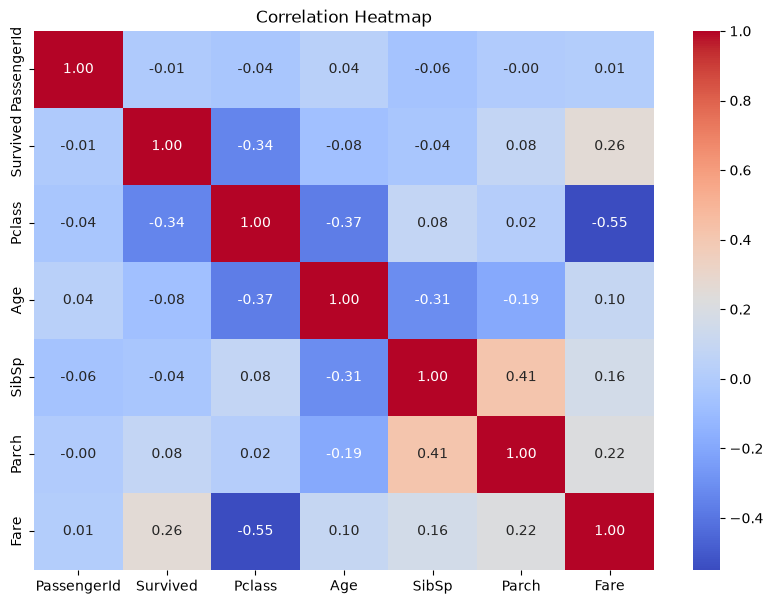

In [21]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()